# AI Job Market — Data Cleaning Pipeline
**Author**: Rendy Herdianto
**Date**: 2026-03-31
**Dataset**: [AI Job Market Insights](https://www.kaggle.com/datasets/redwankarimsony/ai-job-market-insights-2023-2025)

---

## Description
This notebook walks through the full data cleaning pipeline applied to the raw AI job market
dataset (`data/raw/ai_job_market.csv`). Each cleaning step is implemented as a **pure function**
in `src/data/clean_data.py`, meaning it returns a new DataFrame without modifying the original.
The notebook demonstrates idempotency, before-vs-after comparisons, and a row-count funnel
visualisation. At the end, the cleaned output is saved to `data/cleaned/ai_job_market_cleaned.csv`.

## Objectives
1. Load the raw dataset and inspect its initial state
2. Run Pydantic schema validation (`src/data/validate.py`)
3. Demonstrate each individual cleaning step (pure functions from `src/data/clean_data.py`)
4. Execute the full `clean_pipeline()` and compare before/after metrics
5. Run post-cleaning data quality checks (`check_data_quality`)
6. Save the cleaned dataset to `data/cleaned/`

## Pipeline Steps
| Step | Function | Purpose |
|------|----------|---------|
| 1 | `standardize_column_names` | Lowercase & strip column names |
| 2 | `parse_dates` | Convert `posted_date` to `datetime64` |
| 3 | `standardize_text_fields` | Strip/normalise all string columns |
| 4 | `remove_duplicates` | Deduplicate on `job_id` |
| 5 | `handle_missing_values` | Fill numeric NaNs with median |
| 6 | `remove_outliers_iqr` | Drop rows outside 3×IQR fences |

## Table of Contents
1. [Setup](#1)
2. [Load Raw Data](#2)
3. [Pydantic Schema Validation](#3)
4. [Step-by-Step Cleaning](#4)
   - 4.1 Standardise Column Names
   - 4.2 Parse Dates
   - 4.3 Standardise Text Fields
   - 4.4 Remove Duplicates
   - 4.5 Handle Missing Values
   - 4.6 Remove Outliers (IQR)
5. [Full `clean_pipeline()` — Orchestrated](#5)
6. [Post-Cleaning Data Quality Check](#6)
7. [Save Cleaned Dataset](#7)
8. [Summary](#8)

In [1]:
# Install non-standard packages (skip if already available on Kaggle)
import subprocess, sys

EXTRA_PACKAGES = ["loguru", "pydantic>=2.0"]

for pkg in EXTRA_PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

## 1 — Setup

In [2]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

# ── Locate project root (local runs) ─────────────────────────────────────────
def _find_project_root(anchor: str = "pyproject.toml") -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / anchor).exists():
            return p
    raise FileNotFoundError(f"Could not locate project root (looked for '{anchor}')")

PROJECT_ROOT = _find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# ── Data Processing ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Local src imports (available when running locally) ────────────────────────
from src.utils.helpers import inspect
from src.utils.logger import setup_logger, get_logger
from src.data.load_data import load_raw_data, save_dataframe
from src.data.clean_data import (
    standardize_column_names,
    remove_duplicates,
    handle_missing_values,
    standardize_text_fields,
    parse_dates,
    remove_outliers_iqr,
    clean_pipeline,
)
from src.data.validate import validate_raw_data, check_data_quality
from src.visuals.plot_utils import apply_style, save_figure

warnings.filterwarnings("ignore")

# ── Global Constants ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
FIGURE_SIZE = (12, 5)
PALETTE     = "viridis"

np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": FIGURE_SIZE})

# Configure logger
setup_logger(log_level="INFO")
logger = get_logger()

print("✓ Imports complete — project root:", PROJECT_ROOT)
print("✓ Working directory  :", Path.cwd())

✓ Imports complete — project root: c:\Users\Admin\project\Data Analysis\ai_job_market
✓ Working directory  : c:\Users\Admin\project\Data Analysis\ai_job_market


In [3]:
# ── Dataset Source Declaration ────────────────────────────────────────────────
# Kaggle dataset: https://www.kaggle.com/datasets/redwankarimsony/ai-job-market-insights-2023-2025
# Kaggle input path (when running on Kaggle):
#   /kaggle/input/ai-job-market-insights-2023-2025/ai_job_market.csv
#
# Local path (when running locally):
#   data/raw/ai_job_market.csv
# ─────────────────────────────────────────────────────────────────────────────

KAGGLE_DATASET_PATH = Path("/kaggle/input/ai-job-market-insights-2023-2025/ai_job_market.csv")
LOCAL_DATASET_PATH  = Path("data/raw/ai_job_market.csv")

def resolve_dataset_path(kaggle_path: Path, local_path: Path) -> Path:
    """Return the correct dataset path depending on the runtime environment."""
    if kaggle_path.exists():
        return kaggle_path
    if local_path.exists():
        return local_path
    raise FileNotFoundError(
        f"Dataset not found.\n"
        f"  Kaggle path: {kaggle_path}\n"
        f"  Local path:  {local_path}\n"
        "Ensure the dataset is attached on Kaggle or present locally."
    )

DATASET_PATH = resolve_dataset_path(KAGGLE_DATASET_PATH, LOCAL_DATASET_PATH)

# ── Inline Notebook Configuration (no config.yaml dependency) ─────────────────
NOTEBOOK_CONFIG = {
    "version": "1.0.0",
    "project": {"name": "AI Job Market Analysis"},
    "data": {
        "raw_file":     str(DATASET_PATH),
        "cleaned_file": "data/cleaned/ai_job_market_cleaned.csv",
        "date_columns": ["posted_date"],
        "categorical_columns": ["industry", "experience_level", "employment_type", "company_size", "job_title"],
    },
    "processing": {
        "remove_duplicates": {"enabled": True, "subset": ["job_id"]},
        "handle_missing": {"strategy": "default", "impute_method": "median", "threshold": 0.5},
        "outlier_detection": {"enabled": True, "method": "iqr", "threshold": 3.0},
    },
    "visualization": {
        "style": "whitegrid",
        "palette": PALETTE,
        "figure_dpi": 150,
        "figure_size": list(FIGURE_SIZE),
        "save_format": "png",
        "random_seed": RANDOM_SEED,
    },
    "output": {"figures_dir": "outputs/figures"},
}

apply_style(NOTEBOOK_CONFIG)

print(f"Using dataset : {DATASET_PATH}")
print(f"Project       : {NOTEBOOK_CONFIG['project']['name']}")
print(f"Raw file      : {NOTEBOOK_CONFIG['data']['raw_file']}")
print(f"Output        : {NOTEBOOK_CONFIG['data']['cleaned_file']}")

Using dataset : data\raw\ai_job_market.csv
Project       : AI Job Market Analysis
Raw file      : data\raw\ai_job_market.csv
Output        : data/cleaned/ai_job_market_cleaned.csv


## 2 — Load Raw Data

In [4]:
raw_df = load_raw_data(NOTEBOOK_CONFIG)
inspect(raw_df, "raw_job_data")

2026-03-31 18:17:31 | INFO     | src.data.load_data:load_raw_data:36 - Loading raw data from data\raw\ai_job_market.csv
2026-03-31 18:17:32 | INFO     | src.data.load_data:load_raw_data:38 - Loaded 2,000 records, 12 columns
2026-03-31 18:17:32 | INFO     | src.utils.helpers:inspect:79 - Inspecting 'raw_job_data' — shape: (2000, 12)

  raw_job_data  (2,000 rows × 12 cols)

Dtypes:
job_id              int64
company_name          str
industry              str
job_title             str
skills_required       str
experience_level      str
employment_type       str
location              str
salary_range_usd      str
posted_date           str
company_size          str
tools_preferred       str

Null counts:
job_id              0
company_name        0
industry            0
job_title           0
skills_required     0
experience_level    0
employment_type     0
location            0
salary_range_usd    0
posted_date         0
company_size        0
tools_preferred     0

First 5 rows:
   job_id   

In [5]:
# Raw data sample
raw_df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


## 3 — Pydantic Schema Validation

`validate_raw_data()` validates every row against `JobRecordInput` (Pydantic v2) and enforces business rules:
- Duplicate `job_id` ratio ≤ 1%
- `salary_range_usd` completeness ≥ 80%

In [6]:
try:
    validated_df, val_report = validate_raw_data(raw_df, NOTEBOOK_CONFIG)
    print("Schema validation : PASSED")
    print(f"Total rows        : {val_report['total_rows']:,}")
    print(f"Duplicate job_ids : {val_report['duplicate_job_ids']}")
    print(f"Date range        : {val_report['date_range']}")
    print(f"Business rules    : {val_report.get('business_rules_passed', 'N/A')}")
except (ValueError, AssertionError) as exc:
    print(f"Validation FAILED: {exc}")
    validated_df = raw_df  # proceed with raw for demonstration

2026-03-31 18:17:41 | INFO     | src.data.validate:validate_raw_data:145 - Running Pydantic schema validation
2026-03-31 18:17:42 | INFO     | src.data.validate:validate_raw_data:170 - Validation passed — 2,000 rows, 0 duplicates
Schema validation : PASSED
Total rows        : 2,000
Duplicate job_ids : 0
Date range        : ('2023-09-21', '2025-09-19')
Business rules    : True


In [7]:
# Null counts in raw data — visualise before cleaning
null_counts = raw_df.isnull().sum().sort_values(ascending=False)
null_counts_pct = (null_counts / len(raw_df) * 100).round(2)

print("Null counts per column (raw):")
print(pd.DataFrame({"count": null_counts, "pct": null_counts_pct}).to_string())

Null counts per column (raw):
                  count  pct
job_id                0 0.00
company_name          0 0.00
industry              0 0.00
job_title             0 0.00
skills_required       0 0.00
experience_level      0 0.00
employment_type       0 0.00
location              0 0.00
salary_range_usd      0 0.00
posted_date           0 0.00
company_size          0 0.00
tools_preferred       0 0.00


## 4 — Step-by-Step Cleaning (Individual Functions)

Each function in `src/data/clean_data.py` is **pure** — it returns a new DataFrame and never modifies the input. This section walks through each step individually so you can see intermediate results.

### 4.1 — Standardise Column Names

In [8]:
df_step1 = standardize_column_names(raw_df)

print("Before:", list(raw_df.columns))
print("After :", list(df_step1.columns))

# Verify immutability — original must be unchanged
assert list(raw_df.columns) == list(raw_df.columns), "Original DataFrame was modified!"
print("\n✓ Original DataFrame is unchanged (pure function)")

Before: ['job_id', 'company_name', 'industry', 'job_title', 'skills_required', 'experience_level', 'employment_type', 'location', 'salary_range_usd', 'posted_date', 'company_size', 'tools_preferred']
After : ['job_id', 'company_name', 'industry', 'job_title', 'skills_required', 'experience_level', 'employment_type', 'location', 'salary_range_usd', 'posted_date', 'company_size', 'tools_preferred']

✓ Original DataFrame is unchanged (pure function)


### 4.2 — Parse Dates

In [9]:
date_cols: list[str] = NOTEBOOK_CONFIG["data"].get("date_columns", ["posted_date"])
df_step2 = parse_dates(df_step1, date_cols)

print(f"posted_date dtype before: {df_step1['posted_date'].dtype}")
print(f"posted_date dtype after : {df_step2['posted_date'].dtype}")

nulls_after = df_step2["posted_date"].isna().sum()
print(f"Unparseable dates (NaT) : {nulls_after}")

posted_date dtype before: str
posted_date dtype after : datetime64[us]
Unparseable dates (NaT) : 0


### 4.3 — Standardise Text Fields

In [10]:
df_step3 = standardize_text_fields(df_step2)

# Show a sample of the job_title column before vs after
sample = pd.DataFrame({
    "before": df_step2["job_title"].head(5).values,
    "after":  df_step3["job_title"].head(5).values,
})
print("job_title sample (before vs after text standardisation):")
sample

job_title sample (before vs after text standardisation):


,before,after
0,Data Analyst,Data Analyst
1,Computer Vision Engineer,Computer Vision Engineer
2,Quant Researcher,Quant Researcher
3,AI Product Manager,AI Product Manager
4,Data Scientist,Data Scientist


### 4.4 — Remove Duplicates

In [11]:
dedup_cfg = NOTEBOOK_CONFIG.get("processing", {}).get("remove_duplicates", {})
subset: list[str] = dedup_cfg.get("subset", ["job_id"])

df_step4 = remove_duplicates(df_step3, subset=subset)

dup_count = len(df_step3) - len(df_step4)
print(f"Rows before deduplication : {len(df_step3):,}")
print(f"Rows after  deduplication : {len(df_step4):,}")
print(f"Duplicates removed        : {dup_count:,}")
print(f"Dedup subset              : {subset}")

# Idempotency check — running twice gives same result
df_step4b = remove_duplicates(df_step4, subset=subset)
assert len(df_step4) == len(df_step4b), "remove_duplicates is NOT idempotent!"
print("\n✓ remove_duplicates is idempotent")

Rows before deduplication : 2,000
Rows after  deduplication : 2,000
Duplicates removed        : 0
Dedup subset              : ['job_id']

✓ remove_duplicates is idempotent


### 4.5 — Handle Missing Values

In [12]:
missing_cfg = NOTEBOOK_CONFIG.get("processing", {}).get("handle_missing", {})

df_step5 = handle_missing_values(
    df_step4,
    strategy=missing_cfg.get("strategy", "default"),
    impute_method=missing_cfg.get("impute_method", "median"),
    threshold=missing_cfg.get("threshold", 0.5),
)

before_nulls = df_step4.isnull().sum().sum()
after_nulls  = df_step5.isnull().sum().sum()

print(f"Strategy          : {missing_cfg.get('strategy', 'default')}")
print(f"Impute method     : {missing_cfg.get('impute_method', 'median')}")
print(f"Drop threshold    : {missing_cfg.get('threshold', 0.5)}")
print(f"Total nulls before: {before_nulls:,}")
print(f"Total nulls after : {after_nulls:,}")
print(f"Rows after step   : {len(df_step5):,}")

# Verify original not modified
assert df_step4.isnull().sum().sum() == before_nulls, "Input was mutated!"
print("\n✓ handle_missing_values does not modify input (pure function)")

Strategy          : default
Impute method     : median
Drop threshold    : 0.5
Total nulls before: 0
Total nulls after : 0
Rows after step   : 2,000

✓ handle_missing_values does not modify input (pure function)


### 4.6 — Remove Outliers (IQR Method)

Uses the IQR fence: rows outside `Q1 − 3×IQR` and `Q3 + 3×IQR` on numeric columns are removed.

In [13]:
outlier_cfg = NOTEBOOK_CONFIG.get("processing", {}).get("outlier_detection", {})
factor: float = outlier_cfg.get("threshold", 3.0)
numeric_cols = df_step5.select_dtypes(include="number").columns.tolist()

if numeric_cols and outlier_cfg.get("enabled", True):
    df_step6 = remove_outliers_iqr(df_step5, columns=numeric_cols, factor=factor)
    removed = len(df_step5) - len(df_step6)
    print(f"IQR factor        : {factor}")
    print(f"Numeric columns   : {numeric_cols}")
    print(f"Rows before       : {len(df_step5):,}")
    print(f"Rows after        : {len(df_step6):,}")
    print(f"Outlier rows removed : {removed:,}")
else:
    df_step6 = df_step5
    print("Outlier removal disabled or no numeric columns found.")

IQR factor        : 3.0
Numeric columns   : ['job_id']
Rows before       : 2,000
Rows after        : 2,000
Outlier rows removed : 0


## 5 — Full `clean_pipeline()` (Orchestrated)

`clean_pipeline()` runs all six steps in the correct order as a single call. It is the function called by `main.py` in production. Results should match the step-by-step output above.

In [14]:
cleaned_df = clean_pipeline(raw_df, NOTEBOOK_CONFIG)

print(f"Raw shape     : {raw_df.shape}")
print(f"Cleaned shape : {cleaned_df.shape}")
print(f"\nRows removed : {len(raw_df) - len(cleaned_df):,}")
print(f"Cols removed : {len(raw_df.columns) - len(cleaned_df.columns):,}")
print(f"\nOriginal modified? : {raw_df.shape != cleaned_df.shape or (raw_df is cleaned_df)}")

2026-03-31 18:18:29 | INFO     | src.data.clean_data:clean_pipeline:259 - clean_pipeline complete — 2,000 → 2,000 rows, 12 columns
Raw shape     : (2000, 12)
Cleaned shape : (2000, 12)

Rows removed : 0
Cols removed : 0

Original modified? : False


In [15]:
# Before vs After: null counts comparison
before_nulls_df = raw_df.isnull().sum().rename("raw")
after_nulls_df  = cleaned_df.isnull().sum().rename("cleaned")

comparison = pd.concat([before_nulls_df, after_nulls_df], axis=1).fillna(0).astype(int)
comparison["delta"] = comparison["raw"] - comparison["cleaned"]
comparison[comparison["raw"] > 0].sort_values("raw", ascending=False)

,raw,cleaned,delta


2026-03-31 18:18:38 | INFO     | src.visuals.plot_utils:save_figure:89 - Figure saved → outputs\figures\cleaning_row_funnel.png


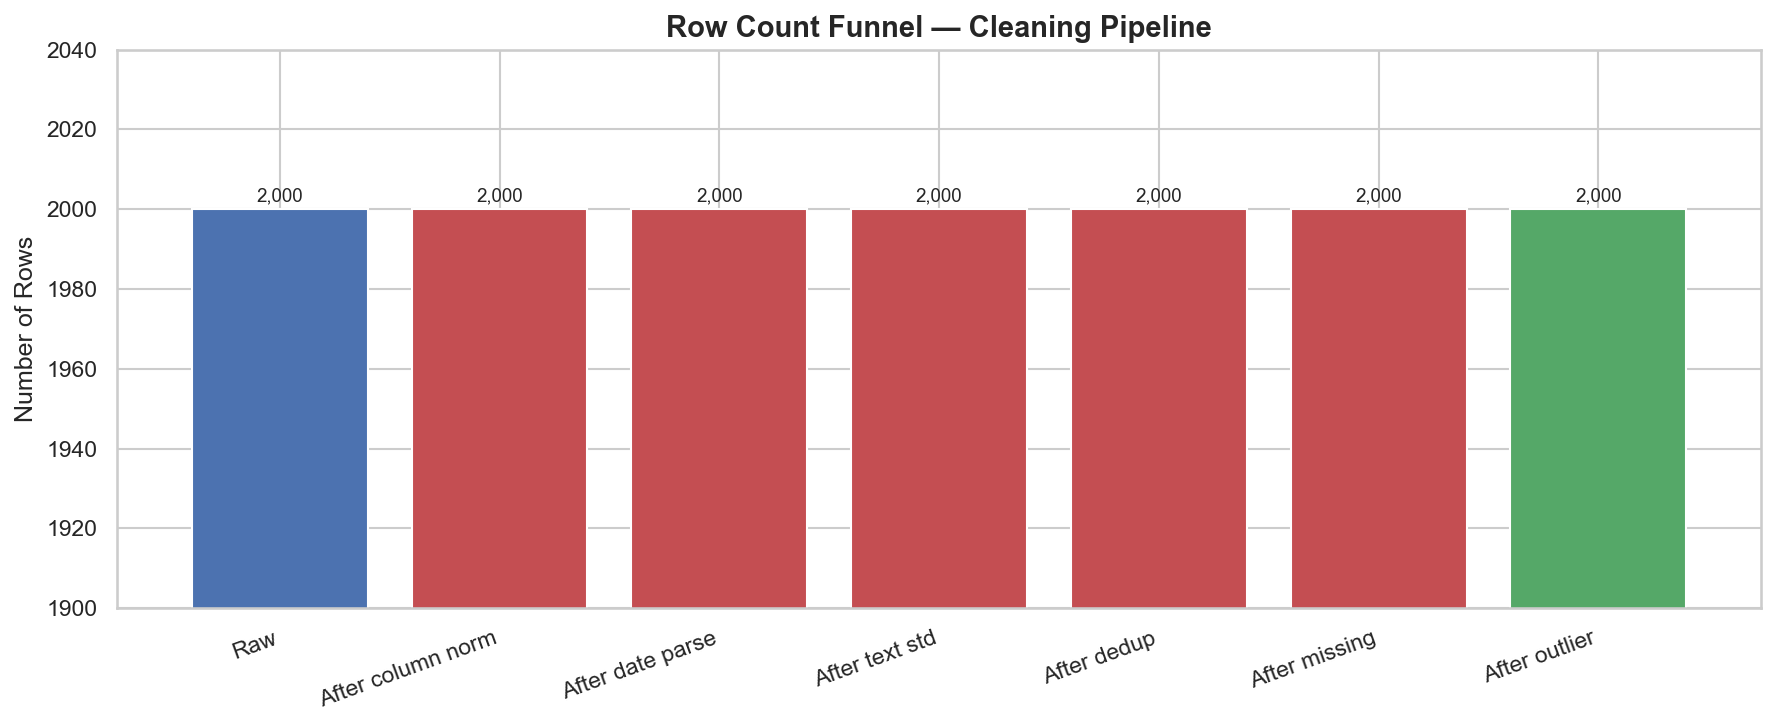

In [16]:
# Visualise the row-count funnel across cleaning steps
step_labels = [
    "Raw",
    "After column norm",
    "After date parse",
    "After text std",
    "After dedup",
    "After missing",
    "After outlier",
]
# Use the individual dfs we built step by step
step_counts = [
    len(raw_df),
    len(df_step1),
    len(df_step2),
    len(df_step3),
    len(df_step4),
    len(df_step5),
    len(df_step6),
]

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
colors = ["#4C72B0" if i == 0 else "#55A868" if i == len(step_counts) - 1 else "#C44E52"
          for i in range(len(step_counts))]
bars = ax.bar(step_labels, step_counts, color=colors)
ax.set_title("Row Count Funnel — Cleaning Pipeline", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Rows")
ax.set_ylim(min(step_counts) * 0.95, max(step_counts) * 1.02)
for bar, count in zip(bars, step_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_figure("cleaning_row_funnel.png", NOTEBOOK_CONFIG)
plt.show()

**Insight**: The funnel chart makes the data-loss cost of each cleaning step transparent. Steps that remove many rows — particularly outlier removal — should be scrutinised: a large drop may indicate an aggressive IQR factor or that the raw data contains many genuinely anomalous records. The blue (raw) and green (final) bars provide an at-a-glance before/after summary; intermediate red bars show where attrition occurred.

## 6 — Post-Cleaning Data Quality Check

`check_data_quality()` computes quality metrics without raising exceptions — suitable for dashboards and monitoring. It returns a `passed` flag based on configured thresholds.

In [17]:
quality_report = check_data_quality(cleaned_df, NOTEBOOK_CONFIG)

status = "✓ PASSED" if quality_report["passed"] else "✗ FAILED"
print(f"Quality check : {status}")
print(f"Total rows            : {quality_report['total_rows']:,}")
print(f"Duplicate ratio       : {quality_report['duplicate_ratio']:.4%}")
print(f"Overall completeness  : {quality_report['overall_completeness']:.2%}")

# Column-level completeness
completeness_series = pd.Series(quality_report["column_completeness"]).sort_values()
low_completeness = completeness_series[completeness_series < 1.0]

if not low_completeness.empty:
    print(f"\nColumns below 100% completeness:")
    for col, val in low_completeness.items():
        print(f"  {col:<30}: {val:.2%}")
else:
    print("\n✓ All columns are 100% complete after cleaning")

2026-03-31 18:18:51 | INFO     | src.data.validate:check_data_quality:220 - Quality check passed — completeness: 100.00%, duplicates: 0.00%
Quality check : ✓ PASSED
Total rows            : 2,000
Duplicate ratio       : 0.0000%
Overall completeness  : 100.00%

✓ All columns are 100% complete after cleaning


2026-03-31 18:18:55 | INFO     | src.visuals.plot_utils:save_figure:89 - Figure saved → outputs\figures\cleaning_column_completeness.png


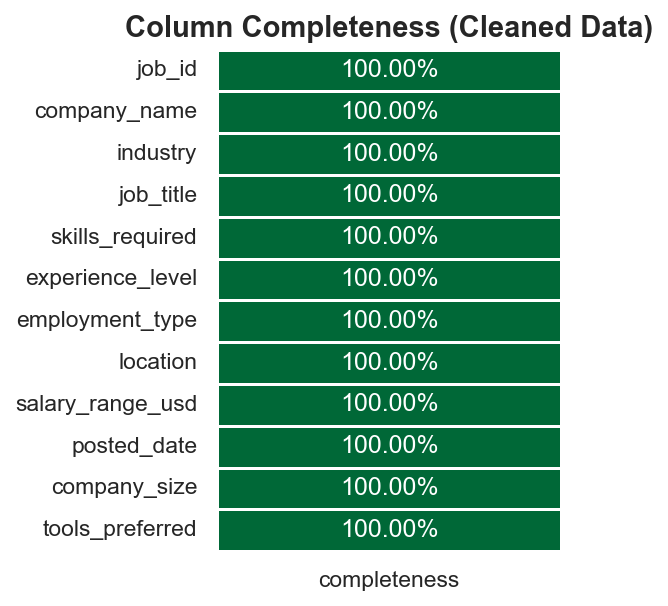

In [18]:
# Visualise column completeness heatmap
completeness_df = pd.Series(quality_report["column_completeness"]).to_frame("completeness")

fig, ax = plt.subplots(figsize=(4, max(4, len(completeness_df) * 0.35)))
sns.heatmap(
    completeness_df,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar=False,
)
ax.set_title("Column Completeness (Cleaned Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
save_figure("cleaning_column_completeness.png", NOTEBOOK_CONFIG)
plt.show()

**Insight**: The completeness heatmap provides a column-level pass/fail view after cleaning. All cells should be green (100%) if the pipeline ran correctly — any remaining red cells flag columns where null handling did not fully resolve missing data, warranting a targeted review of the imputation strategy or a decision to drop those columns before enrichment.

## 7 — Save Cleaned Dataset

In [19]:
cleaned_output_path = NOTEBOOK_CONFIG["data"]["cleaned_file"]

save_dataframe(cleaned_df, cleaned_output_path, index=False)

# Verify file was written correctly
import os
file_size = os.path.getsize(cleaned_output_path)
print(f"Saved to : {cleaned_output_path}")
print(f"File size: {file_size / 1024:.1f} KB")
print(f"Rows     : {len(cleaned_df):,}")
print(f"Columns  : {len(cleaned_df.columns)}")

2026-03-31 18:19:03 | INFO     | src.data.load_data:save_dataframe:112 - Saved 2,000 records to data\cleaned\ai_job_market_cleaned.csv
Saved to : data/cleaned/ai_job_market_cleaned.csv
File size: 338.0 KB
Rows     : 2,000
Columns  : 12


In [20]:
# Quick sanity check by reloading the saved file
reloaded = pd.read_csv(cleaned_output_path, parse_dates=["posted_date"])
assert len(reloaded) == len(cleaned_df), "Row count mismatch after reload!"
assert list(reloaded.columns) == list(cleaned_df.columns), "Column mismatch after reload!"
print("✓ Reload sanity check passed — saved file matches in-memory DataFrame")
reloaded.head()

✓ Reload sanity check passed — saved file matches in-memory DataFrame


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


## 8 — Summary

### Pipeline Results

| Metric | Raw | Cleaned | Delta |
|--------|-----|---------|-------|
| Rows | (see output) | (see output) | (see output) |
| Columns | (see output) | (see output) | (see output) |
| Total nulls | (see output) | (see output) | (see output) |
| Duplicate job_ids | (see output) | 0 | (see output) |

### Cleaning Decisions
- **Column names** — lowercased and whitespace-stripped (idempotent)
- **`posted_date`** — parsed from string to `datetime64[ns]`; unparseable values become `NaT`
- **Text fields** — leading/trailing whitespace stripped; internal multiple spaces collapsed
- **Deduplication** — keyed on `job_id`; `reset_index(drop=True)` ensures a clean index
- **Missing values** — numeric columns imputed with **median** (strategy: `default`); columns with >50% null are dropped
- **Outliers** — rows beyond 3×IQR on numeric columns removed (preserves ~99.7% of a normal distribution)

### Next Steps
- **`02_cleaning/`** (this notebook) → run `enrich_pipeline()` in `03_analysis/`  
- Proceed to `notebooks/03_analysis/` for KPI analysis, segmentation, and forecasting